<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/notebooks/kan_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Знакомство с pykan: установка и базовые туториалы

In [6]:
!pip install git+https://github.com/KindXiaoming/pykan.git

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-_8y2njdb
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-_8y2njdb
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done


**Пример 0: Проверка работы pykan**

Импорт библиотек:

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from kan import KAN

Генерация данных: y = sin(x) + шум

In [8]:
# Генерация данных: y = sin(x) + шум
N = 300  # всего точек
x = torch.linspace(-3, 3, N).reshape(-1, 1)
y = torch.sin(x) + 0.1 * torch.randn_like(x)

# Перемешивание и разбивка данных на train (80%) и test (20%)
N_train = int(0.8 * N)  # 240 точек
indices = torch.randperm(N)  # случайный порядок

train_indices = indices[:N_train]
test_indices = indices[N_train:]

train_x = x[train_indices]; train_y = y[train_indices]
test_x = x[test_indices]; test_y = y[test_indices]

# Сборка датасета
dataset = {
    'train_input': train_x,
    'train_label': train_y,
    'test_input': test_x,
    'test_label': test_y
}

Создание и обучение KAN

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 9.60e-02 | test_loss: 9.50e-02 | reg: 2.46e+00 | : 100%|█| 50/50 [00:01<00:00, 47.38it


saving model version 0.1


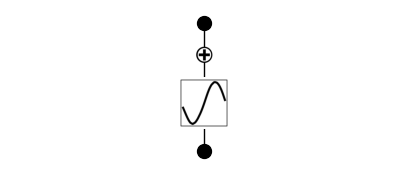

In [9]:
# Создание и обучение KAN
model = KAN(width=[1, 1], grid=5, k=3)
model.fit(dataset=dataset, opt="LBFGS", steps=50)

# Визуализация
model.plot()

(Дополнительно) Как модель предсказывает на тесте

In [10]:
# Как модель предсказывает на обучении и на тесте
with torch.no_grad():
    pred_train = model(train_x)
    pred_test = model(test_x)

# Ошибка на тесте
test_loss = torch.mean((pred_test - test_y)**2)
print(f"Test MSE: {test_loss.item():.6f}")

Test MSE: 0.009020


**Пример 1: Регрессия функции sin(x) с шумом - Туториал "hellokan"**

Подключение библиотек, проверка наличия видеокарты, создание датасета

In [14]:
from kan import *
torch.set_default_dtype(torch.float64) # установление точности

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}") # проверка наличия видеокарты

from kan.utils import create_dataset
# задание обучемой функции f, создание датасета
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = create_dataset(f, n_var=2, device=device)
print("Размер данных:", dataset['train_input'].shape, dataset['train_label'].shape)

Работает на устройстве: cpu
Размер данных: torch.Size([1000, 2]) torch.Size([1000, 1])


Создание KAN 2 входа, 5 скрытых нейронов, 1 выход, грубая сетка (grid=3), кубический сплайн (k=3)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.96e-02 | test_loss: 1.94e-02 | reg: 5.79e+00 | : 100%|█| 50/50 [00:17<00:00,  2.81it


saving model version 0.1
saving model version 0.2


| train_loss: 1.77e-02 | test_loss: 1.70e-02 | reg: 8.16e+00 | : 100%|█| 50/50 [00:11<00:00,  4.37it


saving model version 0.3
saving model version 0.4


| train_loss: 4.64e-04 | test_loss: 4.71e-04 | reg: 8.22e+00 | : 100%|█| 50/50 [00:09<00:00,  5.16it


saving model version 0.5


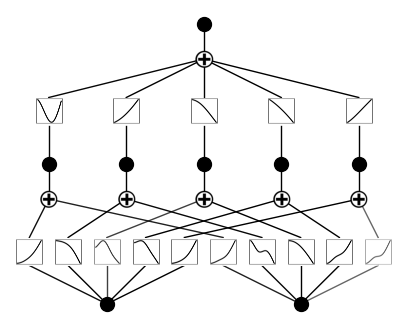

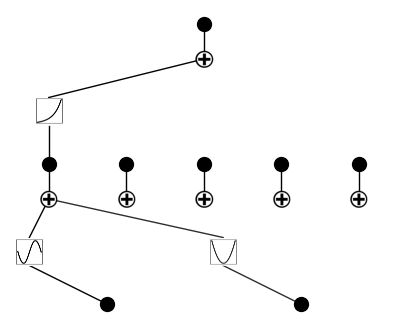

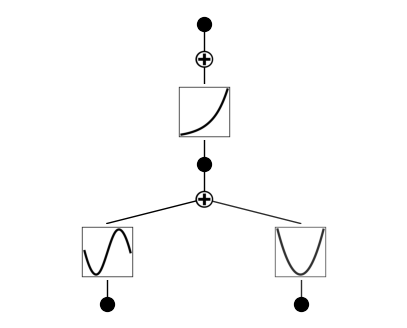

In [17]:
model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)
# создание KAN 2 входа, 5 скрытых нейронов, 1 выход, грубая сетка grid=3, кубический сплайн k=3

# инициализация KAN по данным, визуализация
model(dataset['train_input']);
model.plot()

# обучение сети апроксимировать функцию, визуализация
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001);
model.plot()

# удаление лишних связей, визуализация
model = model.prune()
model.plot()

# продолжение обучения, переобучение с расширением сетки
model.fit(dataset, opt="LBFGS", steps=50);
model = model.refine(10)
model.fit(dataset, opt="LBFGS", steps=50, grid_update_num=25);

Приминение автоматической символьной регрессии

In [20]:
lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
model.auto_symbolic(lib=lib)

from kan.utils import ex_round
ex_round(model.symbolic_formula()[0][0],4)

skipping (0,0,0) since already symbolic
skipping (0,1,0) since already symbolic
skipping (1,0,0) since already symbolic
saving model version 0.7


1.0031*exp(0.999446685795014*x_2**2 + 0.9983*sin(3.1416*x_1)) - 0.003

Приминение ручной символьной регрессии

In [21]:
model.fix_symbolic(0,0,0,'sin');
model.fix_symbolic(0,1,0,'x^2');
model.fix_symbolic(1,0,0,'exp');

from kan.utils import ex_round
ex_round(model.symbolic_formula()[0][0],4)

r2 is 0.9999999195373022
saving model version 0.8
Best value at boundary.
r2 is 0.9999999822013704
saving model version 0.9
Best value at boundary.
r2 is 0.9999996144001405
saving model version 0.10


1.0031*exp(0.999446685795014*x_2**2 + 0.9983*sin(3.1416*x_1)) - 0.003

**Пример 2: Регрессия и символическая регрессия для f(x,y) = exp(sin(πx) + y²) - Туториал "Example_1_function_fitting"**